In [11]:
#@title Installations and importing of packages

# Cloning the proteinMPNN tool from the GitHub repository
!git clone https://github.com/dauparas/ProteinMPNN.git -q

# importing other packages
import os, json, urllib
import numpy as np
from matplotlib import pyplot as plt

# a function to calculate the frequency of mutations at specific positions
def get_mut_counts(wt_seq: str, seqs: list[str]) -> tuple[list[int], list[int]]:
  muts = []
  for m in seqs:
    muts.extend([int(x[1:-1]) for x in get_seq_mutations(wt_seq, m)])
  poses, counts = np.unique(muts, return_counts=True)
  return poses, counts

def get_seq_mutations(s1: str, s2: str) -> list[str]:
  assert len(s1) == len(s2), 'Error: sequences have unequal lengths'
  muts = []
  for p in range(len(s1)):
    if s1[p] != s2[p]:
      muts.append(f'{s1[p]}{p+1}{s2[p]}')
  return muts

fatal: destination path 'ProteinMPNN' already exists and is not an empty directory.


# Usage of ProteinMPNN to predict protein sequences from structure

To get ProteinMPNN description and possible commands:

In [18]:
!python ProteinMPNN/protein_mpnn_run.py --help

usage: protein_mpnn_run.py [-h] [--suppress_print SUPPRESS_PRINT] [--ca_only]
                           [--path_to_model_weights PATH_TO_MODEL_WEIGHTS]
                           [--model_name MODEL_NAME] [--use_soluble_model]
                           [--seed SEED] [--save_score SAVE_SCORE]
                           [--save_probs SAVE_PROBS] [--score_only SCORE_ONLY]
                           [--path_to_fasta PATH_TO_FASTA]
                           [--conditional_probs_only CONDITIONAL_PROBS_ONLY]
                           [--conditional_probs_only_backbone CONDITIONAL_PROBS_ONLY_BACKBONE]
                           [--unconditional_probs_only UNCONDITIONAL_PROBS_ONLY]
                           [--backbone_noise BACKBONE_NOISE]
                           [--num_seq_per_target NUM_SEQ_PER_TARGET]
                           [--batch_size BATCH_SIZE] [--max_length MAX_LENGTH]
                           [--sampling_temp SAMPLING_TEMP]
                           [--out_folder OUT_F

Parameters that must be used for sequence prediction:
- `--pdb-path` - path to file containing protein structure that will be used for structure backbone
- `--path_to_model_weights` - path to model weights. Use `/content/ProteinMPNN/vanilla_model_weights`
- `--out-folder` - name of folder where results will be saved
- `--num_seq_per_target` - number of sequences to generate

In [19]:
!python ProteinMPNN/protein_mpnn_run.py --pdb_path 5HNR.pdb --path_to_model_weights /content/ProteinMPNN/vanilla_model_weights --out_folder results --num_seq_per_target 10

----------------------------------------
chain_id_jsonl is NOT loaded
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: 5HNR
10 sequences of length 656 generated in 75.4742 seconds


The generated sequences will be the same length as the original protein sequence, meaning it is possible to easily find all the mutations that have occurred (no deletions or insertions means we don't need to align sequences):

In [20]:
mpnn_result_filename = 'results/seqs/5HNR.fa'  # proteinMPNN result

with open(mpnn_result_filename, 'r') as f:
  seqs = f.read().splitlines()[1::2]

wt_seq = seqs.pop(0)

seqs


['LPPEEDLSKLWQTPELRAKQSAGTEISPEDLILPIFVTSDENAREPVPKLPGYYRLGVNVLAEYLAPLVAAGLKAVLIHGVPTDTELTETGEAAARGDSPALRAVRLLKAEFPDLTVMVAVNLDHYRKDGLHYLLDXXGKVDLEKTREILAEIALAYAKAGADVIVPESMVDGEVRAIKEKLKKEGLGDKVKVWAYSARFDSPFYGPWVEATGAGPKLGSRADYLIPFGNTELALERAANDVKQGADMLMVDPGILNLDLVRRIKEAFPELPLGVDFVSGEYAAIYHGAAAGAFDLDDAVMEALISFKAAGADYIETFFAPEVLAALK/MDEEEDLRSKFDTPEKQAAQSAGTELTPEDLILPVFVDDDPGARRPVPAMPGVARLGVDTLPAYLAPLVEAGLRAVLIHGVPTGAPLXXXXXXGLAADTPALRAIRLLREAFPDLTVMVVVTLSGGXXXXXXXXXXXXXXXXPRELLDAVADVALAYAEAGAQIIVPENQLDGEVKAIRDRLKANGLGDKVKIWAYSARFDTPFYGGYAAAVXXXXXXXXRSKRLIPPGAVELALRRAAIDVAQGADILSVEPSILNLDLVRRIREAFPDIPLAAVLVSGEYAAIYHGAAAGAFDLDAAVLEALTALKRAGADYIVTYFAPRVLAALA',
 'LPPEEDLTSRFLTPEARAAQSAGTEISPEDLILPVFVTDDRTARIPVPKLPGYHRYGVDVLAEYLAPLVAAGLKAVLIYGVPLNTELTATGEAAARGDSPALRAVRLLKATFPDLTVMVAVNLDFYREHGMPYLLDXXGKLDLEATRERLAAIALAYAKAGADVIVPESSVDGVVRAIKAALAAHGLGDKVKVWAYSARFDSPLYGPWYEATRAYPKLGSRSDYLIPPGARELALQRVANDVREGADMLMVEPGILNLHLIDRIREAFPELPLAVYLVSGEYAAIYEGAKAGAFDYDEAVMEALIAMRAAGADYIVTFFVPEVLKALQ/MKPEEDL

In [21]:
for mut_seq in seqs:
  mutations = []
  for i in range(len(wt_seq)):
    wt_aa = wt_seq[i]
    mut_aa = mut_seq[i]
    if wt_aa != mut_aa:
      mutations.append(f'{wt_aa}{i}{mut_aa}')

  print(f'{len(mutations)} mutations found')

325 mutations found
323 mutations found
316 mutations found
321 mutations found
323 mutations found
328 mutations found
312 mutations found
322 mutations found
315 mutations found
304 mutations found


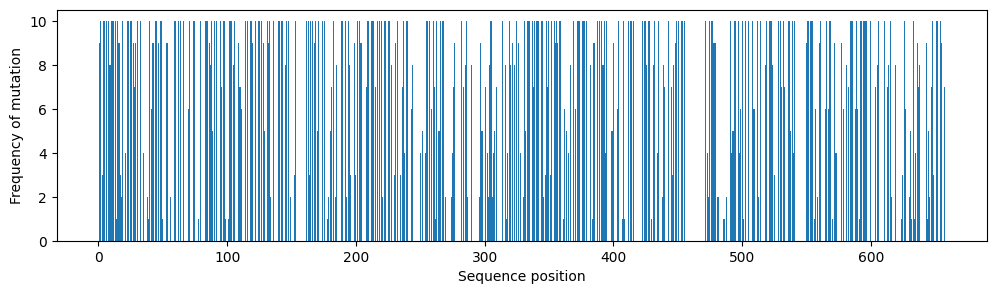

In [22]:
poses, counts = get_mut_counts(wt_seq, seqs)
plt.figure(figsize=(12, 3))
plt.bar(poses, counts)
plt.xlabel('Sequence position')
plt.ylabel('Frequency of mutation')
plt.show()